In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

LIGHT = "#E9E0FF"  
DARK = "#5E2B97"  

LABEL_MAP = {
    0: "Abdomen", 1: "Ankle", 2: "Cervical Spine", 3: "Chest", 4: "Clavicles",
    5: "Elbow", 6: "Feet", 7: "Finger", 8: "Forearm", 9: "Hand", 10: "Hip",
    11: "Knee", 12: "Lower Leg", 13: "Lumbar Spine", 14: "Others", 15: "Pelvis",
    16: "Shoulder", 17: "Sinus", 18: "Skull", 19: "Thigh", 20: "Thoracic Spine",
    21: "Wrist"
}

df_raw = pd.read_csv("/Users/federico/Desktop/progetto VIS/4.1 radiologia/04_radiologia_train.csv")

rows = []
for _, row in df_raw.iterrows():
    targets = str(row["Target"]).strip().split()
    for t in targets:
        rows.append({"SOPInstanceUID": row["SOPInstanceUID"], "Target": int(t)})

df = pd.DataFrame(rows)
df["BodyPart"] = df["Target"].map(LABEL_MAP)

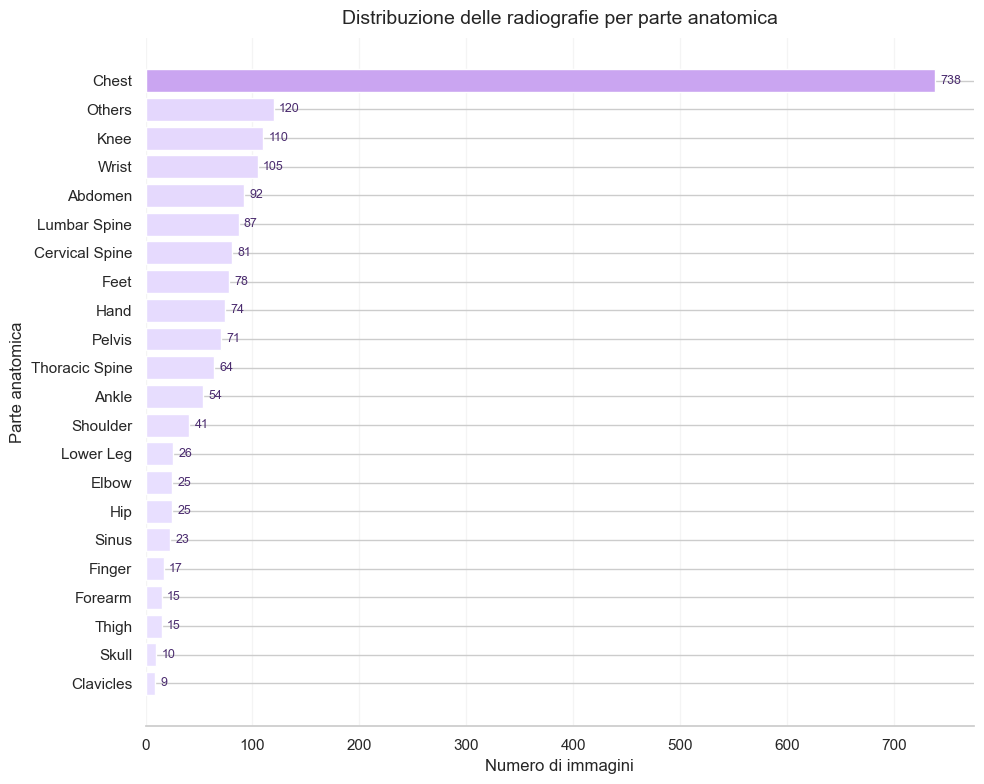

In [2]:
from matplotlib.colors import LinearSegmentedColormap

counts = df["BodyPart"].value_counts().sort_values()

cmap = LinearSegmentedColormap.from_list("lavender_purple", [LIGHT, "#caa5f1"])
norm = plt.Normalize(counts.min(), counts.max())
colors = cmap(norm(counts.values))

plt.figure(figsize=(10, 8))
plt.barh(counts.index, counts.values, color=colors)

plt.title("Distribuzione delle radiografie per parte anatomica", fontsize=14, pad=10)
plt.xlabel("Numero di immagini")
plt.ylabel("Parte anatomica")

for i, v in enumerate(counts.values):
    plt.text(v + 5, i, f"{v:,}".replace(",", "."), va="center", fontsize=9, color="#4B2C6F")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()